In [2]:
from patch_generator_ju_fixed import get_simulation_patch

fits_path = get_simulation_patch(
    logA=3.0,
    Oc0h2=0.12,
    run_id="debug_run_003",
    cleanup=False,
)
fits_path

/rds/rds-clecat/pipeline_alina_full/alina_paper/cosmocnc/cosmocnc/cnc.py:65: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology = cosmology_model(cosmo_params=self.cosmo_params,
/rds/rds-clecat/pipeline_alina_full/alina_paper/pipe_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")
/rds/rds-clecat/pipeline_alina_full/alina_paper/cosmocnc/cosmocnc/cnc.py:138: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology.update_cosmology(cosmo_params,cosmology_tool=self.cnc_params["cosmology_tool"])


Sky frac 0.0024240684055476798
Done: 0 written, 1 skipped.
Execution time: 0.00 seconds.


'/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/mcmc_runs/debug_run_002/3_maps/logA=3_Oc0h2=0.12/y_map_10.0deg_0.500arcmin_0.fits'

In [3]:
import numpy as np
from summary_stat import summary_stat

# 1. Définir la grille ell (nécessaire pour la partie PS)
ell_grid = np.geomspace(400, 5000, 18)

import sys
sys.path.insert(0, "/rds/rds-clecat/pipeline_alina_full/alina_paper/scattering_transform")

# 2. Chemin vers VOTRE fichier unique
# Remplacez par le chemin réel d'un de vos patchs
path_single_fits = "/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/mcmc_runs/debug_run_002/3_maps/logA=3_Oc0h2=0.12/y_map_10.0deg_0.500arcmin_0.fits"

# 3. Appel de la fonction
df_result = summary_stat(
    path_single_fits,
    stat_type="both",         # Calcule WST + PS
    ell_eval=ell_grid,        # Grille de binning
    return_style="pandas",    # "pandas" est plus lisible pour inspecter un seul patch
    wst_kwargs={'J': 7, 'L': 4, 'whiten': False, 'strict_iso': True},
    ps_kwargs={'max_ell': 5000, 'unit_scale': 1e12}
)

# 4. Affichage
print("Résultat pour le patch unique :")
print(df_result.T) # .T (transposée) permet de lire plus facilement en vertical

df_results.to_csv()

use torch backend
Résultat pour le patch unique :
                      0
S0         1.929140e-07
S1_0       2.270779e-08
S1_1       4.357542e-08
S1_2       7.268391e-08
S1_3       9.984340e-08
S1_4       1.078514e-07
S1_5       9.043352e-08
S1_6       6.481125e-08
Dell_400   2.066160e-01
Dell_464   2.863796e-01
Dell_538   2.464812e-01
Dell_624   3.521784e-01
Dell_724   4.135006e-01
Dell_840   4.332517e-01
Dell_975   5.514113e-01
Dell_1131  5.613484e-01
Dell_1312  6.109236e-01
Dell_1523  6.170691e-01
Dell_1767  6.622371e-01
Dell_2050  6.708584e-01
Dell_2378  7.239015e-01
Dell_2759  6.875515e-01
Dell_3201  6.629290e-01
Dell_3714  6.420691e-01
Dell_4309  6.122309e-01
Dell_5000  5.924455e-01


NameError: name 'df_results' is not defined

In [4]:
# ... Suite de votre code (après le print(df_result.T))

import os

# 5. Définir le chemin de sauvegarde
# Crée un nom de fichier basé sur le chemin d'entrée (optionnel, mais propre)
filename_base = os.path.basename(path_single_fits).replace(".fits", "")
output_filename = f"summary_stats_{filename_base}.csv"
output_path = os.path.join(os.path.dirname(path_single_fits), output_filename)

# Option : Si vous voulez le sauvegarder dans le répertoire courant:
# output_path = output_filename 

# 6. Sauvegarde du DataFrame en CSV
try:
    # Sauvegarde la transposée (pour avoir les statistiques en lignes)
    # index=False pour ne pas sauvegarder l'index '0' de la ligne de données
    df_result.T.to_csv(output_path, header=True, index=True)
    print(f"\n✅ Résultat sauvegardé dans : {output_path}")

except Exception as e:
    print(f"\n❌ Erreur lors de la sauvegarde du fichier : {e}")


✅ Résultat sauvegardé dans : /rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/mcmc_runs/debug_run_002/3_maps/logA=3_Oc0h2=0.12/summary_stats_y_map_10.0deg_0.500arcmin_0.csv


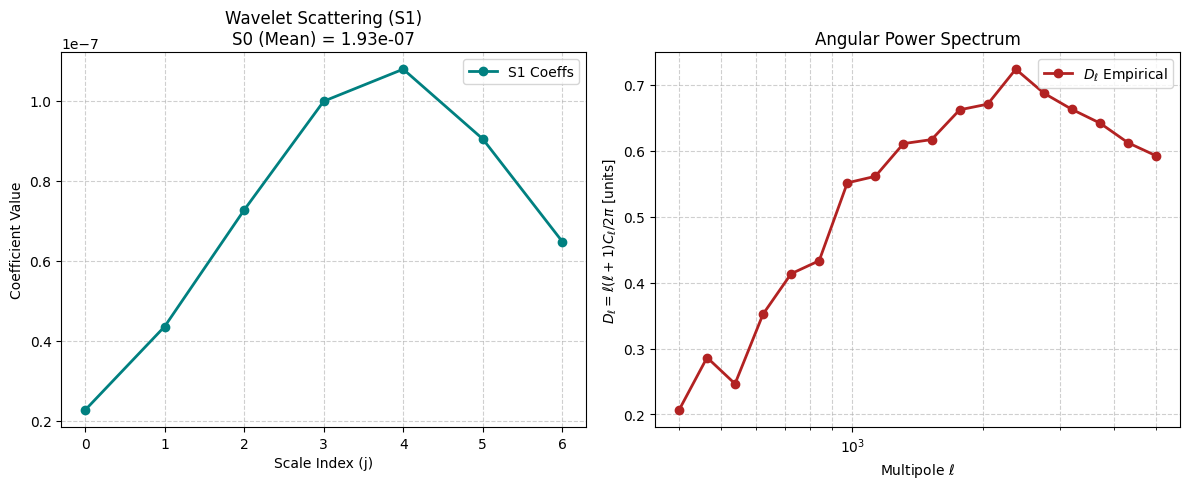

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Supposons que 'df_result' est votre DataFrame obtenu précédemment
# (S'il a une seule ligne, on prend la première : df_result.iloc[0])
row = df_result.iloc[0]

# --- 1. Préparation des données WST (S1) ---
# On filtre les colonnes qui commencent par "S1_"
s1_cols = [c for c in df_result.columns if c.startswith('S1_')]
s1_vals = row[s1_cols].values
s1_x    = range(len(s1_cols)) # Indices 0, 1, 2...

# --- 2. Préparation des données PS (Dell) ---
# On filtre les colonnes "Dell_"
dell_cols = [c for c in df_result.columns if c.startswith('Dell_')]
dell_vals = row[dell_cols].values
# On extrait la valeur de ell depuis le nom de la colonne (ex: "Dell_400" -> 400)
ell_vals  = [float(c.split('_')[1]) for c in dell_cols]


# --- 3. Création du graphique ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# === Plot Gauche : WST S1 ===
ax1 = axes[0]
ax1.plot(s1_x, s1_vals, 'o-', color='teal', lw=2, markersize=6, label='S1 Coeffs')
ax1.set_title(f"Wavelet Scattering (S1)\nS0 (Mean) = {row['S0']:.2e}")
ax1.set_xlabel("Scale Index (j)")
ax1.set_ylabel("Coefficient Value")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# === Plot Droite : Power Spectrum Dell ===
ax2 = axes[1]
ax2.plot(ell_vals, dell_vals, 'o-', color='firebrick', lw=2, markersize=6, label=r'$D_\ell$ Empirical')

# Esthétique pour le spectre
ax2.set_xscale('log')  # L'axe ell est souvent mieux en log
ax2.set_xlabel(r"Multipole $\ell$")
ax2.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell / 2\pi$ [units]")
ax2.set_title("Angular Power Spectrum")
ax2.grid(True, which="both", linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
# Fast version

In [5]:
import os
import sys
import numpy as np
import time
import uuid
import shutil

# Ajout du path courant
sys.path.append(os.getcwd())

# --- IMPORTS ---
# 1. Ton générateur robuste (avec subprocess)
from patch_generator_ju_fixed import get_simulation_patch

# 2. La classe de Likelihood
from likelihood import LikelihoodCalculator

# --- CONFIGURATION ---
PATH_COV = "/rds/rds-clecat/pipeline_alina_full/alina_paper/out/cov_all.npz"  # Ton fichier de cov
PATH_OBS = "/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/mcmc_runs/debug_run_002/3_maps/logA=3_Oc0h2=0.12/y_map_10.0deg_0.500arcmin_0.fits"    # Ton observation
ELL_GRID = np.geomspace(400, 5000, 18)     # Ta grille ell
#/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/mcmc_runs/debug_run_002/3_maps/logA=3_Oc0h2=0.12/summary_stats_y_map_10.0deg_0.500arcmin_0.csv


# Initialisation de la Likelihood (FAIT UNE SEULE FOIS)
# Cela charge la cov, l'inverse, et calcule les stats de l'observation
like_calc = LikelihoodCalculator(
    cov_path=PATH_COV,
    obs_data_path=PATH_OBS,
    ell_grid=ELL_GRID
)
print("Likelihood initialisée.")

# --- FONCTION DE LOG-PROBABILITÉ POUR MCMC ---

def log_prior(theta):
    logA, Oc0h2 = theta
    # Bornes "flat" simples
    if (2.0 < logA < 4.0) and (0.05 < Oc0h2 < 0.20):
        return 0.0
    return -np.inf

def log_probability(theta):
    logA, Oc0h2 = theta
    
    # 1. Check Prior
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    
    # 2. Génération du Patch (Via ton script robuste)
    # On génère un ID unique pour éviter les conflits de fichiers
    unique_id = f"mcmc_{uuid.uuid4().hex[:8]}"
    
    try:
        # Appel de TA fonction get_simulation_patch
        # cleanup=True est important pour supprimer les catalogues intermédiaires
        fits_path = get_simulation_patch(
            logA=logA,
            Oc0h2=Oc0h2,
            run_id=unique_id,
            cleanup=True, 
            beam_fwhm_arcmin=None # ou ta valeur
        )
    except Exception as e:
        print(f"Erreur génération ({unique_id}): {e}")
        # Nettoyage de sécurité si le script a planté avant son cleanup interne
        shutil.rmtree(f"/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/mcmc_runs/{unique_id}", ignore_errors=True)
        return -np.inf

    # 3. Calcul Likelihood
    if fits_path and os.path.exists(fits_path):
        logL = like_calc.compute_loglike(fits_path)
        
        # 4. Nettoyage du FITS final et du dossier parent
        # get_simulation_patch avec cleanup=True laisse quand même le FITS final et le dossier '3_maps'
        try:
            os.remove(fits_path)
            # On remonte pour supprimer le dossier unique créé dans mcmc_runs
            # fits_path est du style: .../mcmc_runs/unique_id/3_maps/.../map.fits
            # On veut supprimer .../mcmc_runs/unique_id
            run_dir = os.path.dirname(os.path.dirname(os.path.dirname(fits_path)))
            if unique_id in run_dir: # Sécurité
                 shutil.rmtree(run_dir, ignore_errors=True)
        except Exception as e:
            print(f"Warning cleanup: {e}")
            
        return lp + logL
    else:
        return -np.inf

# --- TEST UNITAIRE ---
print("Test d'un point...")
t0 = time.time()
val = log_probability([3.0, 0.12])
print(f"LogProb = {val:.4f} (Temps: {time.time()-t0:.2f}s)")

# --- LANCEMENT MCMC (Exemple avec Emcee) ---
import emcee

# Configuration
nwalkers = 8
ndim = 2
# Position initiale petite boule autour d'un point crédible
p0 = [3.0, 0.12] + 1e-2 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

print("Lancement du MCMC...")
# On lance sur peu d'étapes pour tester car chaque étape est lente (subprocess)
sampler.run_mcmc(p0, 10, progress=True)

[Likelihood] Covariance chargée. N_sims=10, p=39
[Likelihood] Structure détectée : WST=8 coeffs, Dell (brut)=31 bins
[Likelihood] Cuts Dell : Head=1, Tail=1


ValueError: Pas assez de simulations (N=10) pour inverser la covariance de taille p=39. Hartlap impossible.